In [1]:
import jax 
import jax.numpy as jnp
import jax.random as jrandom

from probjax.core import log_potential_fn, joint_sample, intervene
from probjax.core.custom_primitives.random_variable import rv 
from probjax.distributions import Normal, Uniform


from probjax.inference.mcmc import MCMC 
from probjax.inference.transition_kernels import GaussianKernel, UniformKernel
from probjax.utils.jaxutils import flatten_fun

In [14]:
import math
sqrt2 = math.sqrt(2)
def simulator_two_moons(key, theta0, theta1):
    """Simulator for the two moons problem."""
    key1, key2 = jrandom.split(key)
    p = rv(Normal(0.1, 0.01), "z1")
    u = rv(Uniform(-0.5 * jnp.pi, 0.5 * jnp.pi), "z2")
    r = p(key1)
    alpha = u(key2)
    rhs1 = (r * jnp.cos(alpha) + 0.25) + (-jnp.abs(theta0 + theta1) / sqrt2)
    rhs2 = (r * jnp.sin(alpha)) + ((theta1 - theta0) / sqrt2)

    return rhs1, rhs2

In [2]:
def f(key):
    key1, key2, key3 = jrandom.split(key, 3)
    theta = rv(Normal(jnp.zeros(10), 1.), "theta")(key1)
    x = rv(Normal(theta + 5., 0.1), "x")(key3)
    return x

In [3]:
conditional = intervene(f, {"x": jnp.array(jnp.ones(10))})

I0000 00:00:1700725125.873670 1868515 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.
No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [4]:
x = f(jrandom.PRNGKey(0))
sampler = joint_sample(conditional)
potential_fn = log_potential_fn(conditional, jrandom.PRNGKey(1))

In [5]:
jaxpr = jax.make_jaxpr(f)(jrandom.PRNGKey(0))

In [6]:
init_samples =  sampler(jrandom.PRNGKey(0))
flat_args,  in_tree = jax.tree_util.tree_flatten(init_samples)

In [7]:
mcmc = MCMC(UniformKernel(), potential_fn, init_samples)

In [8]:
@jax.vmap 
def mcmc_sampling(key):
    return mcmc.run(key,5000)

samples = mcmc_sampling(jrandom.split(jrandom.PRNGKey(0), 1000))

In [12]:
samples["theta"].shape

(1000, 10)

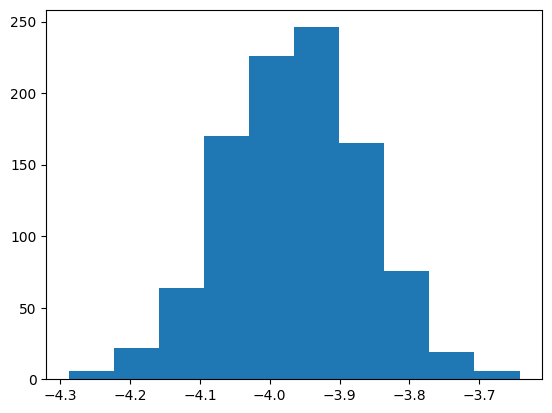

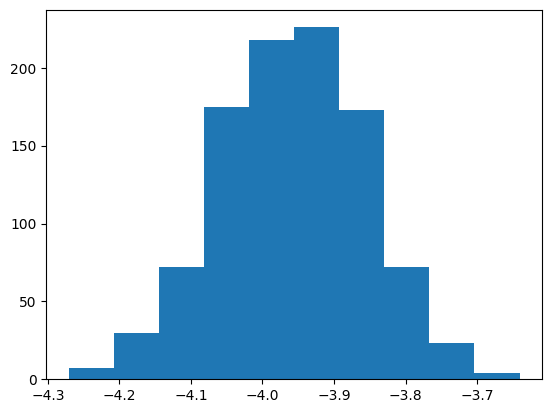

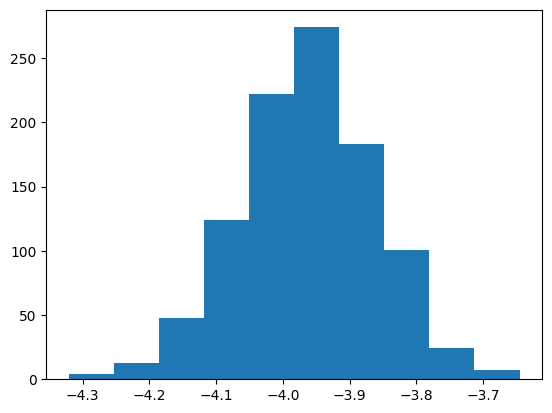

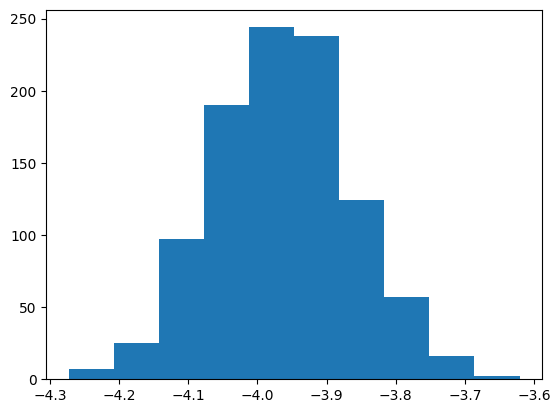

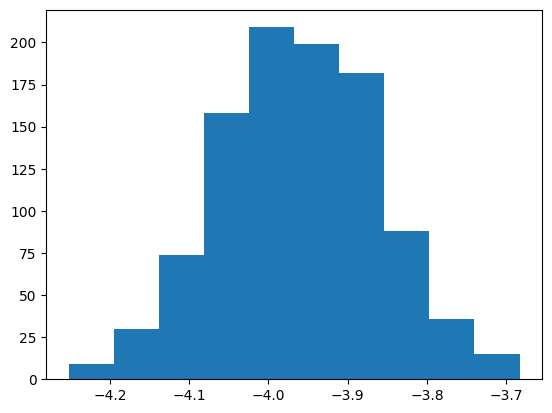

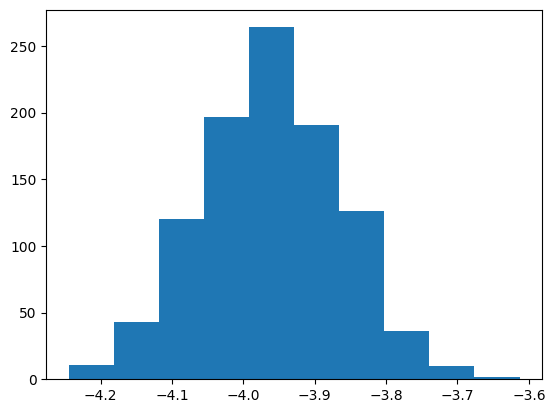

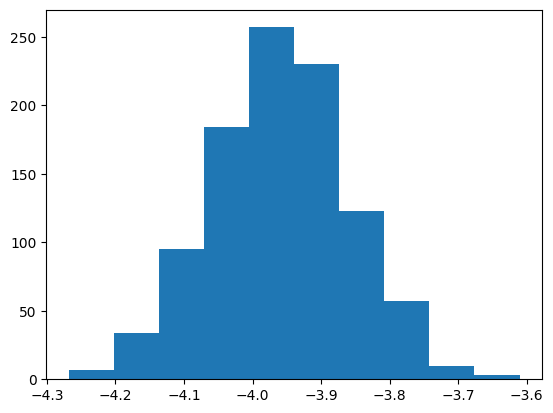

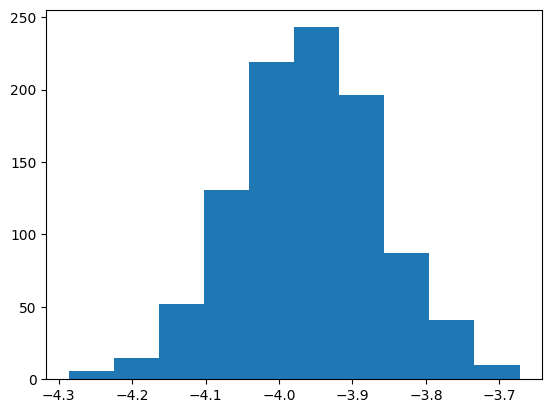

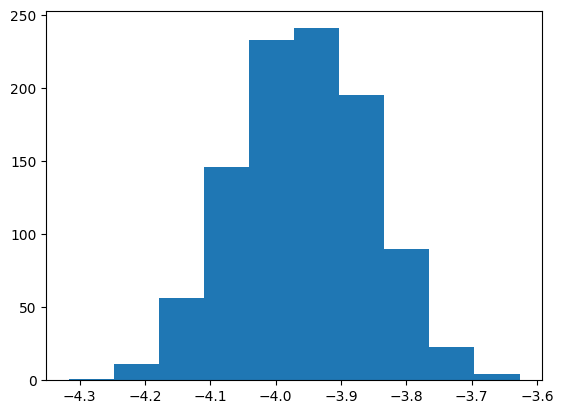

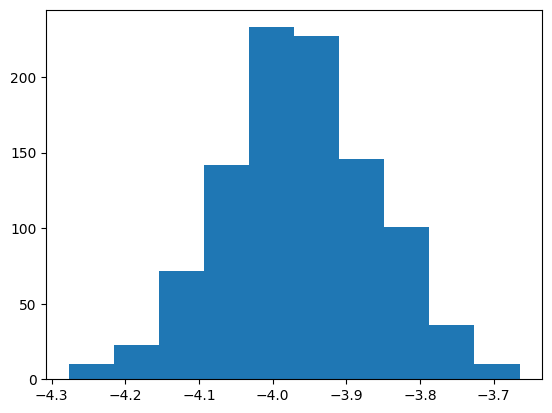

In [13]:
import matplotlib.pyplot as plt

for i in range(10):
    plt.hist(samples["theta"][:,i])
    plt.show()